# Using the Gemini API — A Beginner's Tutorial

In this notebook you'll learn how to:
1. Understand what an API is and why you need an API key
2. Send a text prompt to Gemini and read the response
3. Send an image + question (Visual Question Answering)
4. Explore what the response object actually contains

## Part 1 — What is an API and why do we need a key?

### The server-client model

Google's Gemini model is a **massive** AI running on Google's servers — computers in a data centre, not your laptop.

```
Your laptop  ──── internet ────►  Google's server
(client)         (request)          (runs Gemini)
                                        │
Your laptop  ◄─── internet ──────  answer comes back
                 (response)
```

An **API** (Application Programming Interface) is just a set of rules for how you're allowed to talk to that server — which URLs to call, what data to send, what you'll get back.

### What is an API key?

Imagine the server is a vending machine.  
- Anyone on the internet can knock on the door.  
- But without a coin (your API key) the machine does nothing.  

An API key is a **secret string** (like a long password) that Google gives you when you sign up.  
Every request you send includes this key so the server knows:
- Who is asking
- Whether to charge them
- Whether they've hit their rate limit

> ⚠️ **Never share your API key** — it's linked to your account and can rack up charges.

Get your free key at: https://aistudio.google.com/apikey

## Part 2 — Setup

In [ ]:
# Install the official Google Generative AI SDK (only needed once)
%pip install -q google-genai pillow requests

In [ ]:
from google import genai

# Paste your API key here
API_KEY = ""

# Create a client — this object handles all communication with Google's server
client = genai.Client(api_key=API_KEY)

print("Client ready!")

Client ready!


## Part 3 — Sending a text prompt

The core function is `client.models.generate_content()`.  
You give it:
- `model` — which Gemini version to use
- `contents` — your prompt (just a string for text only)

In [4]:
response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="Tell me a joke."
)

# The simplest way to read the answer
print(response.text)

My wife told me to stop impersonating a flamingo. 

I had to put my foot down.


### What's inside the response object?

`.text` is a handy shortcut, but the full response has more detail.  
Let's peek inside:

In [5]:
# The model can return multiple 'candidates' (alternative answers)
# Usually there's just one
print("Number of candidates:", len(response.candidates))

candidate = response.candidates[0]

# Each candidate has 'content', which contains 'parts'
# A 'part' can be text, an image, etc.
print("\nFinish reason:", candidate.finish_reason)  # why did the model stop?
print("\nParts in the response:")
for part in candidate.content.parts:
    print(" -", part)

Number of candidates: 1

Finish reason: FinishReason.STOP

Parts in the response:
 - media_resolution=None code_execution_result=None executable_code=None file_data=None function_call=None function_response=None inline_data=None text='My wife told me to stop impersonating a flamingo. \n\nI had to put my foot down.' thought=None thought_signature=b'\x12\xf1\n\n\xee\n\x01\x0c9\xd6\xc7E\x0cm1\xd8\xf1\xdc\x0ckg\x8e\xafX/&5\xf7\tx|\xa2.\xd3\x99\xb4\x82(\x9f\x08\xbc\x9f\xa7\x15\xaa\x9c\n\x1e\xe8m\x0c|\xb1\xe4\xc2n\xde\xf0\x98\xe6\xa5X(\x17z\x1f3\xa4\x10\x80\xc1n\xd8\xcd/\xd4\x0b\xfc.\xa52\x116g\x88|\x08\x87\x1a\xb9z\x0b\xf1\rw\n\x1e\xf5\xb1\xa1\xba\x81\x00\xee \xdc\xbd\xb8u\xdaZ,c\xdb\xf8\x15w\x07\x84\r\x8c<\x8f\xf79\xb25&\xdb6\x17&](\xe1|\xa0\x14\x12\x14\xaed\xad\x8f/l\xf1E\x85HF?QM\xf4\xfc\x8c\xc7Sn\xbd^\x12^9\x84\xb8\x10-\'\xa7\xb6\xa7y\x97\x8e\'\xb3;\xdd\x04\x89R\'\xb6|\xa1\xfb\xc6\x93[R\x1c\x83O\xe0#\x05\x81ns\x83XN\xc3\xb9\x80\x8bR\x18\x8f\xa3\xb0\xc1\xd8x\\\xd7\xb5\n\x81\xc1\xe4\x9a\x

In [6]:
# Token usage — useful for understanding cost
# Tokens are chunks of text (~0.75 words each)
usage = response.usage_metadata
print(f"Tokens in your prompt : {usage.prompt_token_count}")
print(f"Tokens in the answer  : {usage.candidates_token_count}")
print(f"Total tokens used     : {usage.total_token_count}")

Tokens in your prompt : 6
Tokens in the answer  : 21
Total tokens used     : 403


**Summary of the response structure:**

```
response
├── .text                          ← shortcut to the answer string
├── .candidates[]                  ← list of alternative answers
│   └── [0]
│       ├── .finish_reason         ← "STOP", "MAX_TOKENS", etc.
│       └── .content
│           └── .parts[]           ← list of text/image pieces
│               └── [0].text       ← the actual text
└── .usage_metadata
    ├── .prompt_token_count
    ├── .candidates_token_count
    └── .total_token_count
```

## Part 4 — Sending an image (Visual Question Answering)

Gemini is **multimodal** — it can look at images and answer questions about them.  
This is called **Visual Question Answering (VQA)**.

All you do differently is pass a **list** for `contents` instead of a single string:

```python
contents = [image, "your question"]
```

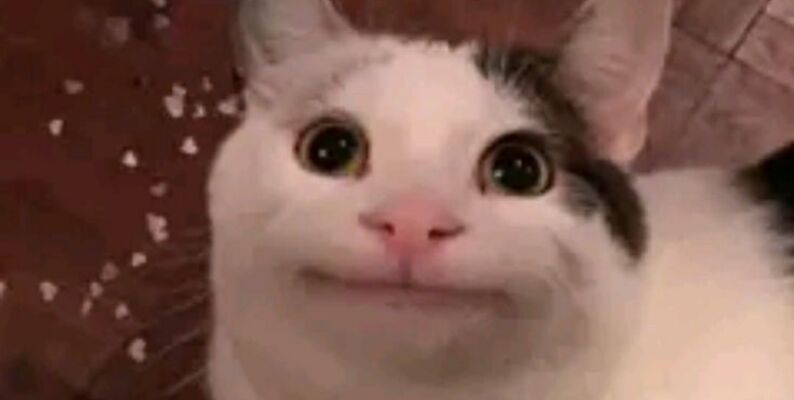

In [7]:
import requests
from PIL import Image
from io import BytesIO

# Download a sample image to work with (a classic PNG transparency demo with dice)
IMAGE_URL = "https://storage.googleapis.com/kaggle-datasets-images/4487470/7689650/46c15968e46396e055bd70889c20613b/dataset-cover.jpg"

img_data = requests.get(IMAGE_URL).content
image = Image.open(BytesIO(img_data))

image  # Jupyter displays PIL images inline

In [ ]:
# Ask Gemini a question about the image
# Contents is now a LIST: [image_object, text_question]
response_vqa = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[image, "What do you see in this image? Describe it simply."]
)

print(response_vqa.text)

This is a close-up image of a white and grey cat looking directly at the camera. The cat has wide, dark eyes and its mouth is pressed tightly together in a straight, flat line, giving it a funny, polite-looking expression. 

This popular image is widely known on the internet as the **"Polite Cat"** meme.


In [9]:
# Try a more specific question
my_question = "How many cats are in the image? Answer only with the number."

response_vqa2 = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[image, my_question]
)

print(f"Question: {my_question}")
print(f"Answer  : {response_vqa2.text}")

Question: How many cats are in the image? Answer only with the number.
Answer  : 1


### Using a local image file instead

If you have your own image saved on your computer, it's just as easy:

In [ ]:
# Edit the path to use your own image
my_image = Image.open("/path/to/your/photo.jpg")

response_local = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[my_image, "What do you see in this image? Describe it simply."]
)
print(response_local.text)

### Capturing an image from your webcam

So far we downloaded an image from the internet. But you can also **take a photo live from your webcam** and send it straight to Gemini.

We use **OpenCV** (`cv2`) for this. OpenCV is a popular computer vision library that can, among many things, talk to your camera hardware.

Here is what the code does step by step:

1. `cv2.VideoCapture(0)` — opens the first camera it finds (index `0` = your built-in webcam)
2. `cap.read()` — grabs one frame; returns a flag (did it work?) and the image as a NumPy array
3. `cv2.cvtColor(...)` — OpenCV stores colours as **BGR** (Blue-Green-Red), but PIL and Gemini expect **RGB**, so we swap the channels
4. `Image.fromarray(...)` — converts the NumPy array into a PIL Image, which is what `generate_content` accepts
5. `cap.release()` — always close the camera when you're done so it's free for other apps

In [10]:
%pip install -q opencv-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
from PIL import Image

cap = cv2.VideoCapture(0)  # 0 = default webcam
ok, frame = cap.read()  # Grab one frame
cap.release()  # Done with the camera

if not ok:
    raise RuntimeError("Could not read from webcam — is it connected?")

# OpenCV gives BGR, convert to RGB for PIL / Gemini
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
webcam_image = Image.fromarray(frame_rgb)

webcam_image   # Preview in Jupyter

In [3]:
# Ask Gemini about whatever the camera just saw
response_cam = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[webcam_image, "What do you see in this image?"]
)

print(response_cam.text)

Based on the image, here is what is visible in the dimly lit room:

1.  **A Floor Lamp:** Located on the far left, featuring a glowing white drum shade that casts a warm light on the wall behind it and the immediate surroundings.
2.  **A Television:** A large, dark rectangular screen is visible to the right of the lamp, apparently turned off.
3.  **A Wall Shelf:** A small, dark wire basket or shelf unit is mounted on the wall above and to the right of the lamp.
4.  **A Tabletop or Tray:** In the bottom-left foreground, there is a round, reflective surface (likely a side table) catching a small amount of light.
5.  **Complete Darkness:** The entire right half and center of the image are pitch black.


## Quick recap

| Concept | What it means |
|---|---|
| **API** | A set of rules for talking to a remote server |
| **API key** | Your secret pass — proves who you are, tracks usage |
| **Client** | Your Python object that handles sending / receiving |
| **`contents`** | Your prompt — a string for text, a list for image + text |
| **`response.text`** | The model's answer as a plain string |
| **Candidates** | Alternative answers the model considered |
| **Tokens** | Chunks of text the model reads/writes (~0.75 words each) |
| **VQA** | Visual Question Answering — asking questions about images |